In [1]:
"""Bayesian Optimization Active Sampling with AP-SSP Planning."""

%load_ext autoreload
%autoreload 2
import jax
from jax import config
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import gpjax as gpx
import optax as ox
import argparse
import sys
import os
from pathlib import Path


def add_project_root_to_path() -> Path:
    project_root = Path.cwd()
    for _ in range(10):
        if (project_root / "src").is_dir() and (project_root / "pixi.toml").exists():
            break
        parent = project_root.parent
        if parent == project_root:
            raise FileNotFoundError(
                "Project root (directory with src/ and pixi.toml) not found."
            )
        project_root = parent
    root_str = str(project_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    return project_root


add_project_root_to_path()

SCRIPT_DIR = Path(__file__).resolve().parent
_parser = argparse.ArgumentParser()
_parser.add_argument(
    "-n",
    "--name",
    default="default",
    help="Subdirectory under plots/bo_active/ for this run's outputs.",
)
_args, _ = _parser.parse_known_args()
RUN_NAME = Path(_args.name).name or "default"
PLOT_RUN_DIR = SCRIPT_DIR / "plots" / "bo_active" / RUN_NAME

from src.env.field.rff_gp_field import RFFGPField
from src.env.actor.grid_actor import GridActor
from src.env.arena.dynamic_sg_arena import DynamicSGArena
from src.env.arena.reward import StepCostReward
from src.env.utils.types import GridConfig, GridPosition
from src.env.rendering.multi_segment_renderer import MultiSegmentRenderer
from src.agents.ap_ssp_agent import APSSPAgent, APSSPAgentConfig

config.update("jax_enable_x64", True)

In [2]:
# 1. Setup True Field and Arena
# =============================
grid_size = 50
subgrid_size = 20
margin = (grid_size - subgrid_size) // 2

sigma_true = 3.0
lengthscale_true = 2.5
nu_true = 2.5
noise_std_true = 0.2
seed = 42
boundary_mode = "terminal"

key = jr.PRNGKey(seed)
key, field_key = jr.split(key)

grid_config = GridConfig.create(n_x=grid_size, n_y=grid_size)
field = RFFGPField(
    config=grid_config,
    d_max=10,
    sigma=sigma_true,
    lengthscale=lengthscale_true,
    nu=nu_true,
    noise_std=noise_std_true,
)
# Build Actor & Arena
actor = GridActor(noise_std=0.0)
vicinity_radius = 0.0
step_cost = 1.0

initial_pos = GridPosition(int(grid_size // 2), int(grid_size // 2))
reward_fn = StepCostReward(
    target_position=initial_pos,
    vicinity_radius=vicinity_radius,
    step_cost=step_cost,
)

arena = DynamicSGArena(
    field=field,
    actor=actor,
    config=grid_config,
    initial_position=initial_pos,
    target_position=initial_pos,
    vicinity_radius=vicinity_radius,
    boundary_mode=boundary_mode,
    vicinity_metric="euclidean",
    reward_fn=reward_fn,
)

key, reset_key = jr.split(key)
arena.reset(reset_key)
true_u = field._precomputed_u.squeeze()
true_u_subgrid = true_u[margin:-margin, margin:-margin]
assert jnp.array_equal(true_u, field._precomputed_u.squeeze()), (
    "Field was re-sampled unexpectedly!"
)

W0416 17:27:27.694190 3622041 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [3]:
# Plan AP-SSP
print(f"Planning AP-SSP for all state-goal pairs ({grid_size}x{grid_size}) ...")
agent = APSSPAgent(APSSPAgentConfig(max_iters=500, rel_tol=1e-3))
agent.plan(arena)
print("Planning complete!")

Planning AP-SSP for all state-goal pairs (50x50) ...
AP-SSP converged in 1000 iters (max_diff=5.374025)
Planning complete!


In [4]:
# Setup Full GP Test Grid for predictions
x_coords_full = jnp.arange(1, grid_size + 1)
y_coords_full = jnp.arange(1, grid_size + 1)
Xm_full, Ym_full = jnp.meshgrid(x_coords_full, y_coords_full, indexing="ij")
X_test_full = jnp.column_stack([Xm_full.ravel(), Ym_full.ravel()]).astype(jnp.float64)

# Setup Subgrid for Targeting and RMSE
x_coords_sub = jnp.arange(margin + 1, grid_size - margin + 1)
y_coords_sub = jnp.arange(margin + 1, grid_size - margin + 1)
Xm_sub, Ym_sub = jnp.meshgrid(x_coords_sub, y_coords_sub, indexing="ij")
X_test_sub = jnp.column_stack([Xm_sub.ravel(), Ym_sub.ravel()]).astype(jnp.float64)

var_init = sigma_true**2
lengthscale_init = lengthscale_true

In [5]:
# 2. General Evaluation and Acquisition Functions
# ===============================================
def deduplicate_observations(X_obs_list, y_obs_list):
    """Average observations at the same (i,j) cell to reduce redundancy."""
    from collections import defaultdict

    cell_obs = defaultdict(list)
    for xy, y_val in zip(X_obs_list, y_obs_list):
        cell_obs[(xy[0], xy[1])].append(y_val[0])
    X_dedup, y_dedup = [], []
    for (i, j), vals in cell_obs.items():
        X_dedup.append([i, j])
        y_dedup.append([float(jnp.mean(jnp.array(vals)))])
    return X_dedup, y_dedup


def evaluate_gp(X_tr, y_tr, optimize=False, alpha=None, init_params=None):
    """Fit GP and return predictions, RMSE, and learned params for warm-starting."""
    # Deduplicate observations at same grid cell
    X_dedup, y_dedup = deduplicate_observations(X_tr.tolist(), y_tr.tolist())
    dataset = gpx.Dataset(
        X=jnp.array(X_dedup, dtype=jnp.float64),
        y=jnp.array(y_dedup, dtype=jnp.float64),
    )

    # Use warm-started params if available, otherwise use initial values
    v_init = init_params["variance"] if init_params else var_init
    l_init = init_params["lengthscale"] if init_params else lengthscale_init

    kernel = gpx.kernels.Matern52(variance=v_init, lengthscale=l_init)
    prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
    likelihood = gpx.likelihoods.Gaussian(
        num_datapoints=dataset.n, obs_stddev=jnp.array([noise_std_true])
    )
    posterior = prior * likelihood

    learned_params = None
    if optimize:

        def nmll(p, d):
            return -gpx.objectives.conjugate_mll(p, d)

        optim = ox.adam(learning_rate=0.05)
        opt_posterior, _ = gpx.fit(
            model=posterior,
            objective=nmll,
            train_data=dataset,
            optim=optim,
            num_iters=300,
        )
        latent_dist = opt_posterior.predict(X_test_full, train_data=dataset)
        learned_params = {
            "variance": opt_posterior.prior.kernel.variance,
            "lengthscale": opt_posterior.prior.kernel.lengthscale,
        }
    else:
        latent_dist = posterior.predict(X_test_full, train_data=dataset)

    mu_full = latent_dist.mean.reshape(grid_size, grid_size)
    var_full = latent_dist.variance.reshape(grid_size, grid_size)

    # Calculate RMSE values
    mu_subgrid = mu_full[margin:-margin, margin:-margin]
    true_u_flat_full = true_u.ravel()
    mu_flat_full = mu_full.ravel()
    true_u_flat_sub = true_u_subgrid.ravel()
    mu_flat_sub = mu_subgrid.ravel()

    rmse_dict = {
        "rmse_full_grid": float(
            jnp.sqrt(jnp.mean((true_u_flat_full - mu_flat_full) ** 2))
        ),
        "rmse_subgrid": float(jnp.sqrt(jnp.mean((true_u_flat_sub - mu_flat_sub) ** 2))),
    }

    if alpha is not None:
        mask = jnp.abs(true_u_flat_sub) > alpha
        if jnp.sum(mask) == 0:
            rmse_dict["rmse_subgrid_levelset"] = 0.0
            print("No points in level set")
        else:
            rmse_dict["rmse_subgrid_levelset"] = float(
                jnp.sqrt(jnp.mean((true_u_flat_sub[mask] - mu_flat_sub[mask]) ** 2))
            )

    return mu_full, var_full, rmse_dict, learned_params


def ei_acq(mu_flat, var_flat, y_train):
    f_best = jnp.max(jnp.abs(y_train))
    abs_mu = jnp.abs(mu_flat)
    sigma = jnp.sqrt(jnp.maximum(var_flat, 1e-9))
    z = (abs_mu - f_best) / sigma
    phi = jax.scipy.stats.norm.pdf(z)
    Phi = jax.scipy.stats.norm.cdf(z)
    ei = (abs_mu - f_best) * Phi + sigma * phi
    return jnp.where(sigma > 1e-6, ei, 0.0)


def thompson_acq(mu_flat, var_flat, key):
    """Thompson sampling: draw from GP posterior marginals, pick argmax |sample|."""
    sigma = jnp.sqrt(jnp.maximum(var_flat, 1e-9))
    samples = mu_flat + sigma * jr.normal(key, shape=mu_flat.shape)
    return jnp.abs(samples)

In [6]:
# 3. Trajectory Loop Function
# ===========================
def run_trajectory_loops(
    acq_type,
    strategy_key,
    max_total_samples=150,
    max_steps_per_loop=30,
    alpha=None,
    gif_path=None,
    optimize=True,
):
    key = strategy_key
    print(f"\n--- Running Strategy: {acq_type} ---")

    # Optional renderer for trajectory GIF
    renderer = None
    if gif_path is not None:
        renderer = MultiSegmentRenderer(
            config=grid_config,
            show_grid_points=True,
            width=900,
            height=900,
            field=field,
            show_field=True,
        )

    # Reset so each strategy / re-run starts at step 0 (no field re-sample)
    obs = arena.reset_counters_and_position(initial_pos)

    X_obs = []
    y_obs = []

    # Initial sample
    key, noise_key = jr.split(key)
    disp = field.sample_displacement(initial_pos, noise_key)
    X_obs.append([initial_pos.i, initial_pos.j])
    y_obs.append([disp.u])

    rmse_history = []
    f_star = float(jnp.max(jnp.abs(true_u_subgrid)))
    max_observed_abs = 0.0
    cumulative_regret = 0.0
    regret_history = []  # (num_samples, cumulative_regret, simple_regret)

    # Regret for initial sample
    _pi, _pj = initial_pos.i, initial_pos.j
    if (margin + 1 <= _pi <= margin + subgrid_size) and (
        margin + 1 <= _pj <= margin + subgrid_size
    ):
        _val = float(jnp.abs(true_u[_pi - 1, _pj - 1]))
        max_observed_abs = max(max_observed_abs, _val)
        cumulative_regret += f_star - _val
    regret_history.append((1, cumulative_regret, f_star - max_observed_abs))

    loop_idx = 1
    gp_params = None  # warm-start params
    targets_attempted = 0
    targets_reached = 0

    while len(X_obs) < max_total_samples:
        X_tr = jnp.array(X_obs, dtype=jnp.float64)
        y_tr = jnp.array(y_obs, dtype=jnp.float64)

        mu, var, rmse_dict, gp_params = evaluate_gp(
            X_tr, y_tr, optimize=optimize, alpha=alpha, init_params=gp_params
        )
        rmse_history.append((len(X_obs), rmse_dict))
        print(
            f"Loop {loop_idx} | Samples: {len(X_obs)}/{max_total_samples} | RMSE(sub): {rmse_dict['rmse_subgrid_levelset']:.4f}"
        )

        # Extract subgrid predictions for targeting
        mu_subgrid = mu[margin:-margin, margin:-margin]
        var_subgrid = var[margin:-margin, margin:-margin]

        mu_flat = mu_subgrid.ravel()
        var_flat = var_subgrid.ravel()

        current_pos = arena.position

        # Mask points already in vicinity to avoid "vicinity trap"
        dist_to_current = jnp.sqrt(
            (X_test_sub[:, 0] - current_pos.i) ** 2
            + (X_test_sub[:, 1] - current_pos.j) ** 2
        )
        valid_mask = dist_to_current > vicinity_radius

        if acq_type == "random":
            key, subkey = jr.split(key)
            valid_indices = jnp.where(valid_mask)[0]
            if len(valid_indices) == 0:
                print("  -> No valid targets left outside vicinity. Terminating early.")
                break
            idx_of_idx = jr.randint(subkey, (), 0, len(valid_indices))
            best_idx = int(valid_indices[idx_of_idx])
        elif acq_type == "max_variance":
            acq = jnp.where(valid_mask, var_flat, -jnp.inf)
            best_idx = int(jnp.argmax(acq))
        elif acq_type == "ei":
            acq = ei_acq(mu_flat, var_flat, y_tr)
            acq = jnp.where(valid_mask, acq, -jnp.inf)
            best_idx = int(jnp.argmax(acq))
        elif acq_type == "cost_aware_ei":
            acq = ei_acq(mu_flat, var_flat, y_tr)
            costs_full = agent._cost_table[current_pos.i - 1, current_pos.j - 1, :, :]
            costs_subgrid = costs_full[margin:-margin, margin:-margin]
            costs = costs_subgrid.ravel()

            costs = jnp.maximum(costs, 1.0)
            acq_cost_aware = acq / costs
            acq_cost_aware = jnp.where(valid_mask, acq_cost_aware, -jnp.inf)
            best_idx = int(jnp.argmax(acq_cost_aware))
        elif acq_type == "thompson":
            key, ts_key = jr.split(key)
            acq = thompson_acq(mu_flat, var_flat, ts_key)
            acq = jnp.where(valid_mask, acq, -jnp.inf)
            best_idx = int(jnp.argmax(acq))
        else:
            raise ValueError(f"Unknown acq_type: {acq_type}")

        target_coords = X_test_sub[best_idx]
        target_pos = GridPosition(int(target_coords[0]), int(target_coords[1]))
        targets_attempted += 1

        print(f"  -> Target: {target_pos} from {arena.position}")

        # Navigate to target
        arena.set_target(target_pos)
        agent.set_target(target_pos)
        obs = arena.soft_reset()

        if renderer is not None:
            renderer.new_segment()
            renderer.step(arena.get_state())

        action = agent.begin_episode(obs)
        steps_this_loop = 0
        crashed = False

        while steps_this_loop < max_steps_per_loop and len(X_obs) < max_total_samples:
            obs = arena.step(action)
            reward = arena.compute_reward()
            state = arena.get_state()

            if renderer is not None:
                renderer.step(state)

            # Record observation
            key, noise_key = jr.split(key)
            disp = field.sample_displacement(state.last_position, noise_key)
            X_obs.append([state.last_position.i, state.last_position.j])
            y_obs.append([disp.u])
            steps_this_loop += 1

            # Track regret (subgrid observations only)
            _pi, _pj = state.last_position.i, state.last_position.j
            if (margin + 1 <= _pi <= margin + subgrid_size) and (
                margin + 1 <= _pj <= margin + subgrid_size
            ):
                _val = float(jnp.abs(true_u[_pi - 1, _pj - 1]))
                max_observed_abs = max(max_observed_abs, _val)
                cumulative_regret += f_star - _val
            regret_history.append(
                (len(X_obs), cumulative_regret, f_star - max_observed_abs)
            )

            if state.target_reached:
                targets_reached += 1
                print(f"  -> Reached in {steps_this_loop} steps.")
                break
            if arena.is_terminal():
                print(f"  -> Out of bounds at {state.last_position}! Robot crashed.")
                arena.set_position(initial_pos)
                crashed = True
                break

            action = agent.step(reward, obs)

        if crashed:
            print("  -> Ending data collection for this strategy early due to crash.")
            break

        loop_idx += 1

    # Final eval
    X_tr = jnp.array(X_obs, dtype=jnp.float64)
    y_tr = jnp.array(y_obs, dtype=jnp.float64)
    mu, var, rmse_dict, gp_params = evaluate_gp(
        X_tr, y_tr, optimize=optimize, alpha=alpha, init_params=gp_params
    )
    rmse_history.append((len(X_obs), rmse_dict))

    if renderer is not None and gif_path is not None:
        os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)
        renderer.save_gif(gif_path, fps=5)
        print(f"  -> Trajectory GIF saved to {gif_path}")
        renderer.reset()

    print(
        f"Final | Samples: {len(X_obs)} | Reach: {targets_reached}/{targets_attempted}"
        f" | RMSE(subgrid): {rmse_dict['rmse_subgrid']:.4f}"
        f" | Cum. Regret: {cumulative_regret:.2f}"
    )
    return (
        mu,
        var,
        X_tr,
        y_tr,
        rmse_history,
        (targets_reached, targets_attempted),
        regret_history,
    )

In [7]:
# 4. Run Experiments
# ==================
max_total_samples = 500
max_steps_per_loop = 50
eval_alpha = 6.0  # Set to a threshold to estimate level sets, or None for whole subgrid

results = {}
strategies = ["random", "max_variance", "ei", "cost_aware_ei", "thompson"]
labels = ["Random Target", "Max Variance", "EI", "Cost-Aware EI", "Thompson"]

PLOT_RUN_DIR.mkdir(parents=True, exist_ok=True)
for idx, strat in enumerate(strategies):
    strategy_key = jr.fold_in(jr.PRNGKey(seed), idx)
    gif_path = str(PLOT_RUN_DIR / f"trajectory_{strat}.gif")
    results[strat] = run_trajectory_loops(
        strat,
        strategy_key=strategy_key,
        max_total_samples=max_total_samples,
        max_steps_per_loop=max_steps_per_loop,
        alpha=eval_alpha,
        gif_path=gif_path,
        optimize=False,
    )

# Print comparison table
print("\n=== Strategy Comparison ===")
print(
    f"{'Strategy':<30} {'Samples':>8} {'Reach':>12} {'RMSE(grid)':>12} {'RMSE(sub)':>12} {'RMSE(lvl)':>12} {'Cum.Regret':>12} {'Simp.Regret':>12}"
)
print("-" * 118)
for strat, label in zip(strategies, labels):
    _, _, X_tr, _, rmse_hist, reach_info, regret_hist = results[strat]
    reached, attempted = reach_info
    rd = rmse_hist[-1][1]
    lvl_str = f"{rd.get('rmse_subgrid_levelset', float('nan')):>12.4f}"
    reach_str = f"{reached:>3}/{attempted:<3}"
    final_cum_regret = regret_hist[-1][1] if regret_hist else 0.0
    final_simple_regret = regret_hist[-1][2] if regret_hist else 0.0
    print(
        f"{label:<30} {len(X_tr):>8} {reach_str:>12}"
        f"{rd['rmse_full_grid']:>12.4f}{rd['rmse_subgrid']:>12.4f}{lvl_str}"
        f"{final_cum_regret:>12.2f}{final_simple_regret:>12.4f}"
    )


--- Running Strategy: random ---


  0%|          | 0/300 [00:00<?, ?it/s]

Loop 1 | Samples: 1/150 | RMSE(sub): 5.8178
  -> Target: GridPosition(i=35, j=27, k=None) from GridPosition(i=25, j=25, k=None)
  -> Reached in 30 steps.


  0%|          | 0/300 [00:00<?, ?it/s]

Loop 2 | Samples: 31/150 | RMSE(sub): 5.9852
  -> Target: GridPosition(i=33, j=26, k=None) from GridPosition(i=35, j=27, k=None)


...

Loop 7 | Samples: 108/150 | RMSE(sub): 5.4400
  -> Target: GridPosition(i=24, j=19, k=None) from GridPosition(i=16, j=35, k=None)
  -> Reached in 26 steps.


  0%|          | 0/300 [00:00<?, ?it/s]

Loop 8 | Samples: 134/150 | RMSE(sub): 4.4679
  -> Target: GridPosition(i=18, j=33, k=None) from GridPosition(i=24, j=19, k=None)


  0%|          | 0/300 [00:00<?, ?it/s]

GIF saved to: plots/bo_active/trajectory_thompson.gif  (157 frames, 2110.9 KB)
  -> Trajectory GIF saved to plots/bo_active/trajectory_thompson.gif
Final | Samples: 150 | Reach: 5/8 | RMSE(subgrid): 1.6787 | Cum. Regret: 620.19

=== Strategy Comparison ===
Strategy                        Samples        Reach   RMSE(grid)    RMSE(sub)    RMSE(lvl)   Cum.Regret  Simp.Regret
----------------------------------------------------------------------------------------------------------------------
Random Target                       150        5/8        3.1308      2.1252      5.1386      825.03      2.1308
Max Variance                        150        4/7        2.8826      1.4463      1.8180      628.04      0.0000
EI                                  150        5/9        3.1141      1.8468      4.4251      713.49      2.2397
Cost-Aware EI                       150       31/32       3.0908      1.7409      4.3050      851.56      1.6681
Thompson                            150        5/8    

In [19]:
# 5. Plotting
# ===========
PLOT_RUN_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)

colors = ["b", "g", "r", "purple", "orange"]
markers = ["o", "s", "^", "D", "v"]

_extent = [0.5, grid_size + 0.5, 0.5, grid_size + 0.5]
_sub_extent = [
    margin + 0.5,
    margin + subgrid_size + 0.5,
    margin + 0.5,
    margin + subgrid_size + 0.5,
]
_cx = np.arange(1, grid_size + 1)
_cy = np.arange(1, grid_size + 1)


def _add_subgrid_rect(ax, edgecolor="white"):
    ax.add_patch(
        patches.Rectangle(
            (margin + 0.5, margin + 0.5),
            subgrid_size,
            subgrid_size,
            linewidth=1.5,
            edgecolor=edgecolor,
            facecolor="none",
            linestyle="--",
        )
    )

Saved posteriors plot to plots/bo_active/bo_posteriors.png


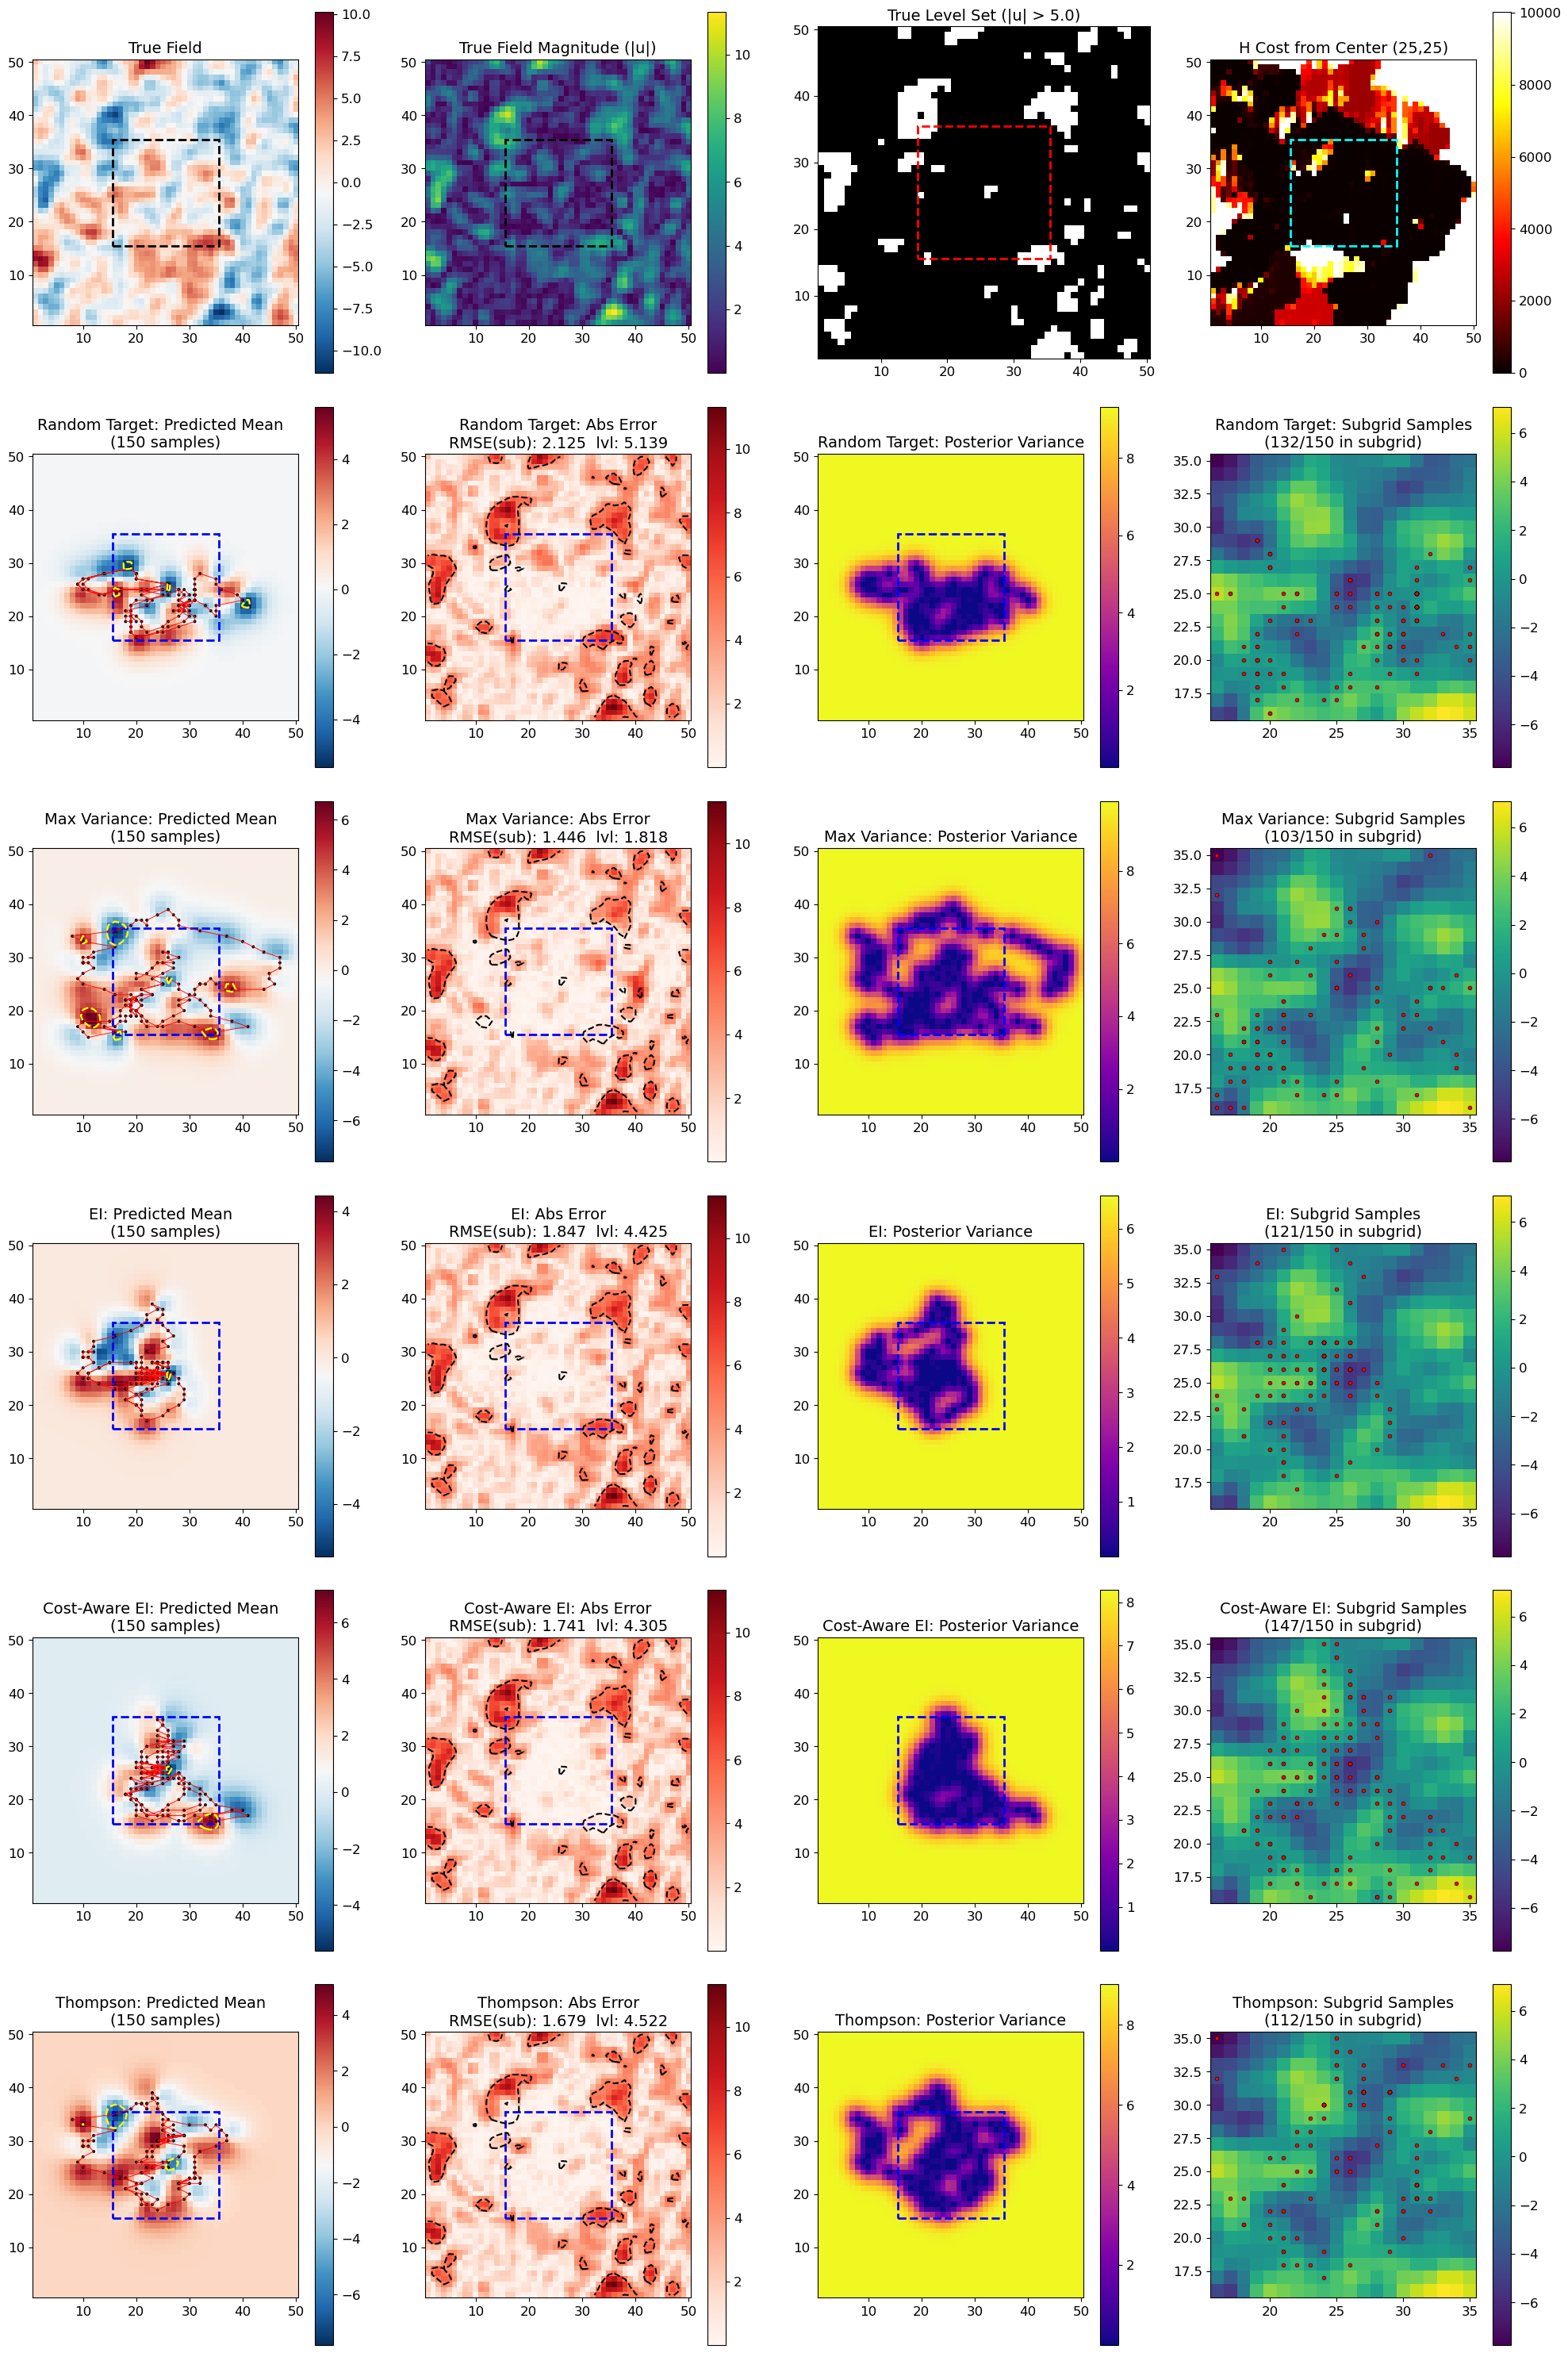

In [20]:
# Figure 1: Posteriors grid (6×4)
# ================================
fig, axes = plt.subplots(6, 4, figsize=(20, 30))

# Row 0: Ground truth overview
im0 = axes[0, 0].imshow(true_u.T, origin="lower", cmap="RdBu_r", extent=_extent)
axes[0, 0].set_title("True Field")
_add_subgrid_rect(axes[0, 0], edgecolor="black")
plt.colorbar(im0, ax=axes[0, 0])

im0_mag = axes[0, 1].imshow(
    jnp.abs(true_u).T, origin="lower", cmap="viridis", extent=_extent
)
axes[0, 1].set_title("True Field Magnitude (|u|)")
_add_subgrid_rect(axes[0, 1], edgecolor="black")
plt.colorbar(im0_mag, ax=axes[0, 1])

if eval_alpha is not None:
    mask_plot = (jnp.abs(true_u) > eval_alpha).astype(float)
    im0_mask = axes[0, 2].imshow(
        mask_plot.T, origin="lower", cmap="gray", extent=_extent
    )
    axes[0, 2].set_title(f"True Level Set (|u| > {eval_alpha})")
    _add_subgrid_rect(axes[0, 2], edgecolor="red")
else:
    axes[0, 2].axis("off")

cost_from_center = agent._cost_table[initial_pos.i - 1, initial_pos.j - 1, :, :]
im0_h = axes[0, 3].imshow(
    cost_from_center.T, origin="lower", cmap="hot", extent=_extent
)
axes[0, 3].set_title(f"H Cost from Center ({initial_pos.i},{initial_pos.j})")
_add_subgrid_rect(axes[0, 3], edgecolor="cyan")
plt.colorbar(im0_h, ax=axes[0, 3])

# Rows 1-5: Per-strategy
for i, strat in enumerate(strategies):
    r = i + 1
    mu, var, X_tr, y_tr, rmse_hist, reach_info, regret_hist = results[strat]
    final_rd = rmse_hist[-1][1]

    # Col 0: Predicted mean + trajectory + estimated level set contour
    im_m = axes[r, 0].imshow(mu.T, origin="lower", cmap="RdBu_r", extent=_extent)
    axes[r, 0].plot(X_tr[:, 0], X_tr[:, 1], color="white", alpha=0.4, linewidth=0.8)
    axes[r, 0].scatter(X_tr[:, 0], X_tr[:, 1], c="red", s=8, edgecolors="none")
    if eval_alpha is not None:
        axes[r, 0].contour(
            _cx,
            _cy,
            jnp.abs(mu).T,
            levels=[eval_alpha],
            colors="yellow",
            linewidths=1.5,
            linestyles="--",
        )
    _add_subgrid_rect(axes[r, 0])
    axes[r, 0].set_title(f"{labels[i]}: Predicted Mean  ({len(X_tr)} samples)")
    plt.colorbar(im_m, ax=axes[r, 0])

    # Col 1: Absolute error + true level set contour
    err = jnp.abs(true_u - mu)
    im_e = axes[r, 1].imshow(err.T, origin="lower", cmap="Reds", extent=_extent)
    if eval_alpha is not None:
        axes[r, 1].contour(
            _cx,
            _cy,
            jnp.abs(true_u).T,
            levels=[eval_alpha],
            colors="black",
            linewidths=1.5,
            linestyles="--",
        )
    title_rmse = f"RMSE(sub): {final_rd['rmse_subgrid']:.3f}"
    if eval_alpha is not None and "rmse_subgrid_levelset" in final_rd:
        title_rmse += f"  lvl: {final_rd['rmse_subgrid_levelset']:.3f}"
    axes[r, 1].set_title(f"{labels[i]}: Abs Error\n{title_rmse}")
    _add_subgrid_rect(axes[r, 1])
    plt.colorbar(im_e, ax=axes[r, 1])

    # Col 2: Posterior variance
    im_v = axes[r, 2].imshow(var.T, origin="lower", cmap="plasma", extent=_extent)
    axes[r, 2].set_title(f"{labels[i]}: Posterior Variance")
    _add_subgrid_rect(axes[r, 2])
    plt.colorbar(im_v, ax=axes[r, 2])

    # Col 3: Sample scatter on subgrid true field
    im_f = axes[r, 3].imshow(
        true_u_subgrid.T, origin="lower", cmap="viridis", extent=_sub_extent
    )
    in_sub = (
        (X_tr[:, 0] >= margin + 1)
        & (X_tr[:, 0] <= margin + subgrid_size)
        & (X_tr[:, 1] >= margin + 1)
        & (X_tr[:, 1] <= margin + subgrid_size)
    )
    axes[r, 3].scatter(
        X_tr[in_sub, 0], X_tr[in_sub, 1], c="red", s=12, edgecolors="k", linewidths=0.4
    )
    axes[r, 3].set_title(
        f"{labels[i]}: Subgrid Samples\n({int(in_sub.sum())}/{len(X_tr)} in subgrid)"
    )
    plt.colorbar(im_f, ax=axes[r, 3])

plt.tight_layout()
posteriors_path = PLOT_RUN_DIR / "bo_posteriors.png"
plt.savefig(posteriors_path, dpi=150)
print(f"Saved posteriors plot to {posteriors_path}")
plt.show()

Saved metrics dashboard to plots/bo_active/bo_metrics_dashboard.png


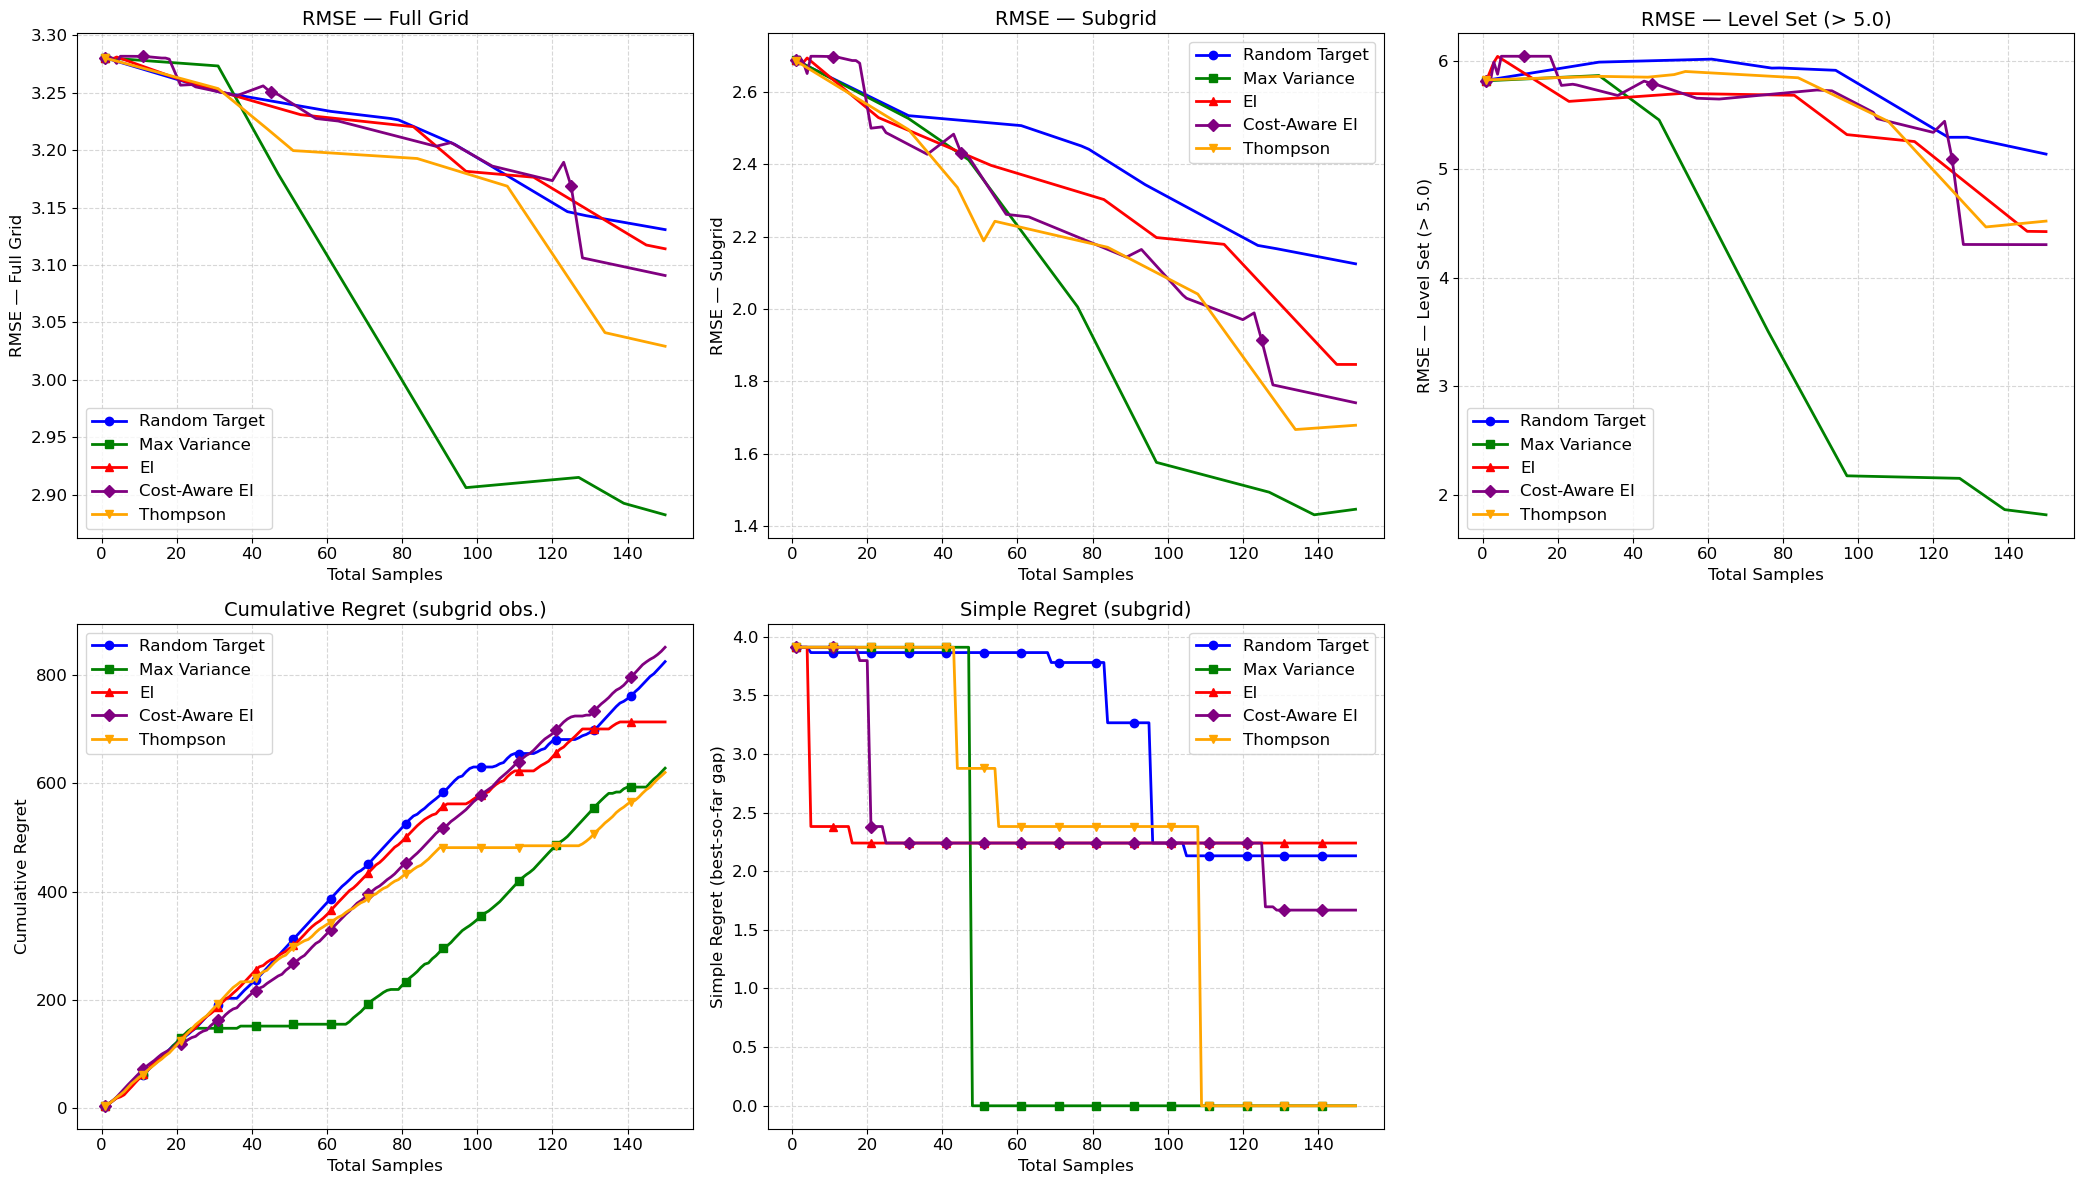

In [21]:
# Figure 2: Metrics Dashboard (2×3)
# ==================================
fig_dash, axes_dash = plt.subplots(2, 3, figsize=(21, 12))

rmse_keys = ["rmse_full_grid", "rmse_subgrid"]
rmse_titles = ["RMSE — Full Grid", "RMSE — Subgrid"]
if eval_alpha is not None:
    rmse_keys.append("rmse_subgrid_levelset")
    rmse_titles.append(f"RMSE — Level Set (> {eval_alpha})")

for col, (rkey, rtitle) in enumerate(zip(rmse_keys, rmse_titles)):
    ax = axes_dash[0, col]
    for i, strat in enumerate(strategies):
        rmse_hist = results[strat][4]
        xs = [x[0] for x in rmse_hist]
        ys = [x[1][rkey] for x in rmse_hist]
        ax.plot(
            xs,
            ys,
            marker=markers[i],
            color=colors[i],
            label=labels[i],
            linewidth=2,
            markevery=10,
        )
    ax.set_xlabel("Total Samples")
    ax.set_ylabel(rtitle)
    ax.set_title(rtitle)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

for i, strat in enumerate(strategies):
    regret_hist = results[strat][6]
    xs = [r[0] for r in regret_hist]
    cum_ys = [r[1] for r in regret_hist]
    simp_ys = [r[2] for r in regret_hist]
    axes_dash[1, 0].plot(
        xs,
        cum_ys,
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        linewidth=2,
        markevery=10,
    )
    axes_dash[1, 1].plot(
        xs,
        simp_ys,
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        linewidth=2,
        markevery=10,
    )

axes_dash[1, 0].set_xlabel("Total Samples")
axes_dash[1, 0].set_ylabel("Cumulative Regret")
axes_dash[1, 0].set_title("Cumulative Regret (subgrid obs.)")
axes_dash[1, 0].legend()
axes_dash[1, 0].grid(True, linestyle="--", alpha=0.5)

axes_dash[1, 1].set_xlabel("Total Samples")
axes_dash[1, 1].set_ylabel("Simple Regret (best-so-far gap)")
axes_dash[1, 1].set_title("Simple Regret (subgrid)")
axes_dash[1, 1].legend()
axes_dash[1, 1].grid(True, linestyle="--", alpha=0.5)

axes_dash[1, 2].axis("off")

plt.tight_layout()
dashboard_path = PLOT_RUN_DIR / "bo_metrics_dashboard.png"
plt.savefig(dashboard_path, dpi=150)
print(f"Saved metrics dashboard to {dashboard_path}")
plt.show()